# LoRA on MNIST

This notebook will attempt to implement Low-Rank Adaptation(LoRA) Finetuning from scratch on the MNIST dataset using pytorch lightning. I'm purposely using a simple model and data that way I can focus on LoRA implementation. 

Plan
1. Build an MLP. Train this model to perform well on MNIST 0-4 (half of the data).
3. Use standard finetuning approach to train this model to work on MNIST 5-9 (this will act as our baseline)
4. Use LoRA finetuning to train the original model to work on MNIST 5-9
5. Compare finetuning techniques (performance, memory etc)


Sources:
1. https://arxiv.org/abs/2106.09685 - LoRA paper
2. https://lightning.ai/pages/community/tutorial/lora-llm/ - (The first half offers useful starter pseudocode)
3. https://colab.research.google.com/drive/1iERDk94Jp0UErsPf7vXyPKeiM4ZJUQ-a?usp=sharing#scrollTo=WuK0lPwcB7Ia - had some good ideas on metrics to compute about LoRA-ized model
4. https://lightning.ai/docs/pytorch/stable/notebooks/lightning_examples/mnist-hello-world.html - starter code for building an MLP and training on MNIST
5. https://discuss.pytorch.org/t/how-to-use-one-class-of-number-in-mnist/26276/21 - forum post on how to limit MNIST to only first or second half

In [29]:
%pip install -U -q lightning

In [30]:
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import LearningRateFinder
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from pytorch_lightning import Callback

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torch.utils.data.sampler import SubsetRandomSampler

import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms
from torchmetrics import Accuracy

import pandas as pd
import seaborn as sn
import math
import matplotlib.pyplot as plt

In [31]:
# set precision to what lightning suggests for this gpu
torch.set_float32_matmul_precision('high')

# make results reproducible
L.seed_everything(42)

INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


42

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import os

PATH_DATASETS = "/content/drive/MyDrive/colab_data/mnist_project"
os.makedirs(PATH_DATASETS, exist_ok=True)

print("Save dir:", PATH_DATASETS)

Save dir: /content/drive/MyDrive/colab_data/mnist_project


In [34]:
class LitMNIST(L.LightningModule):
    def __init__(
            self,
            data_dir=PATH_DATASETS,
            hidden_size=64,
            lr=2e-4
    ):
        super().__init__()

        # set our init args as class attributes
        self.data_dir = data_dir
        self.hidden_size = hidden_size
        self.lr = lr

        # hardcode some dataset specific attributes
        self.class_names = [0, 1, 2, 3, 4]
        self.min_class = min(self.class_names)
        self.num_classes = len(self.class_names)
        self.dims = (1, 28, 28)
        channels, width, height = self.dims

        self.tranform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize((0.1307, ), (0.3081, ))
            ]
        )

        self.batch_size = 1024

        # Define layers for model
        self.l1 = nn.Linear(
            channels * width * height,
            hidden_size
        )
        self.l2 = nn.Linear(
            hidden_size,
            hidden_size
        )
        self.l3 = nn.Linear(
            hidden_size,
            self.num_classes
        )
        self.dropout = nn.Dropout(0.1)
        self.relu = nn.ReLU()

        # define metrics
        self.val_accuracy = Accuracy(
            task="multiclass",
            num_classes=self.num_classes
        )
        self.test_accuracy = Accuracy(
            task="multiclass",
            num_classes=self.num_classes
        )


    def forward(self, x):
        # preproecessing
        x = torch.flatten(x, 1)

        x = self.l1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.l2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.l3(x)
        # notice that we return the log probabilities here as that is what nll loss expects in the training step
        return F.log_softmax(x, dim=1)
    

    def common_step(self, batch, batch_idx):
        # define steps all of {train, val, test} will take in one place
        x, y = batch
        # rescale y to be 0 indexed if necessary (like when we start using mnist 5-9)
        if self.min_class != 0:
            y = y - self.min_class
        
        logits = self(x)
        loss = F.nll_loss(logits, y)
        return x,y, logits, loss
    
    def training_step(self, batch, batch_idx):
        _, _, _, loss = self.common_step(batch, batch_idx)
        self.log("train_loss", loss, batch_size=self.batch_size)
        return loss
    
    def validation_step(
            self,
            batch,
            batch_idx
    ):
        x, y, logits, loss = self.common_step(batch, batch_idx)
        preds = torch.argmax(logits, dim=1)
        self.val_accuracy.update(preds, y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_accuracy, prog_bar=True)

    def test_step(
            self, 
            batch, 
            batch_idx
    ):
        x, y, logits, loss = self.common_step(batch, batch_idx)
        preds = torch.argmax(logits, dim=1)
        self.test_accuracy.update(preds, y)

        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_accuracy, prog_bar=True)

    
    def configure_optimizers(self):
        # we'll use adamw to match the paper
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.lr
        )
        return optimizer
    
    # the rest of the class is helper functions/hooks for configuring data/dataloader building
    @staticmethod
    def get_indices(dataset,class_names):
        if isinstance(dataset, torch.utils.data.dataset.Subset):
            targets = torch.tensor([dataset.dataset.targets[i] for i in dataset.indices])
        else:
            targets = dataset.targets

            
        indices =  []
        for i in range(len(targets)):
            if targets[i] in class_names:
                indices.append(i)
        return indices
    
    def create_dataloader(self,dataset):
        idx = self.get_indices(dataset, self.class_names)
        loader = DataLoader(dataset,batch_size=self.batch_size, sampler = SubsetRandomSampler(idx), num_workers=16) # Note - this necessarily shuffles the data due to the sampler we are using
        return loader
    

    def prepare_data(self):
        # download data
        MNIST(self.data_dir, train=True, download=True)
        MNIST(self.data_dir, train=False, download=True)

    
    def setup(
            self,
            stage=None
    ):
        # assign train/val datasets for use in dataloaders
        if stage == "fit" or stage is None:
            mnist_full = MNIST(
                self.data_dir,
                train=True,
                transform=self.tranform
            )

            self.mnist_train, self.mnist_val = random_split(
                mnist_full,
                [55000, 5000]
            )

        # assign test dataset for use in dataloader(s)
        if stage == "test" or stage is None:
            self.mnist_test = MNIST(
                self.data_dir,
                train=False,
                transform=self.tranform
            )

    def train_dataloader(self):
        return self.create_dataloader(self.mnist_train)

    def val_dataloader(self):
        return self.create_dataloader(self.mnist_val)

    def test_dataloader(self):
        return self.create_dataloader(self.mnist_test)


In [35]:
model = LitMNIST()

In [36]:
log_dir = os.path.join(PATH_DATASETS, "logs")

In [42]:
import lightning as L
import lightning.pytorch as pl

pl.__version__ = L.__version__

print("L version:", L.__version__)
print("pl version:", pl.__version__)

L version: 2.6.5
pl version: 2.6.5


In [43]:
trainer = L.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=10,
    logger=CSVLogger(save_dir=log_dir)
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [44]:
trainer.fit(model)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ l1            │ Linear             │ 50.2 K │ train │     0 │
│ 1 │ l2            │ Linear             │  4.2 K │ train │     0 │
│ 2 │ l3            │ Linear             │    325 │ train │     0 │
│ 3 │ dropout       │ Dropout            │      0 │ train │     0 │
│ 4 │ relu          │ ReLU               │      0 │ train │     0 │
│ 5 │ val_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 6 │ test_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 54.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 54.7 K                                                                                               
Total estimated model params size (MB): 0.219                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


,train_loss,val_acc,val_loss
epoch,,,
0,NaN,0.928401,0.466512
1,0.313636,NaN,NaN
1,NaN,0.940334,0.247901
2,NaN,0.954654,0.175758
3,0.193542,NaN,NaN


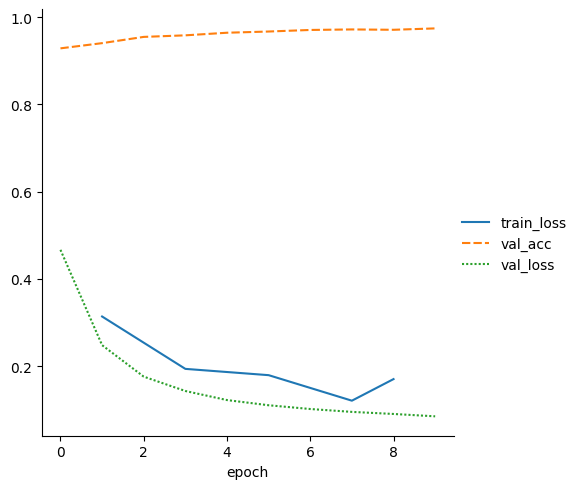

In [45]:
metrics = pd.read_csv(
    f"{trainer.logger.log_dir}/metrics.csv"
)

del metrics["step"]

metrics.set_index("epoch", inplace=True)

display(metrics.dropna(axis=1, how="all").head())

sn.relplot(
    data=metrics,
    kind="line"
)

In [46]:
# as expected out model performs well
trainer.test()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/colab_data/mnist_project/logs/lightning_logs/version_3/checkpoints/epoch=9-step=280.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded 

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9756761789321899     │
│         test_loss         │    0.08203138411045074    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.08203138411045074, 'test_acc': 0.9756761789321899}]

In [53]:
trainer.save_checkpoint("model.ckpt")

INFO: `weights_only` was not set, defaulting to `False`.
INFO: `weights_only` was not set, defaulting to `False`.
INFO: `weights_only` was not set, defaulting to `False`.
INFO: `weights_only` was not set, defaulting to `False`.
INFO: `weights_only` was not set, defaulting to `False`.
INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


In [54]:
torch.save(model.state_dict(), 'model.pt')

# Finetune on second half of MNIST

In [55]:
# load the model - we refer to it as "no training" as we are going to use this initialization
# to show that the model performs poorly on the second half of mnist (as it wasn't trained on it)
model_loaded_no_training = LitMNIST.load_from_checkpoint(
    checkpoint_path="model.ckpt"
)

In [56]:
# set ut up to run on the second half of mnist (digits 5, 6, 7, 8, 9)
model_loaded_no_training.class_names = [5, 6, 7, 8, 9]

In [57]:
model_loaded_no_training.min_class = min(model_loaded_no_training.class_names)

In [58]:
# we will train on the new data on exactly one element once (this is so we can access the trainer2.test())
# function, which allow us to easily evaluate how well our mmodel works on the new data prior to training)
model_loaded_no_training.batch_size = 1

In [59]:
trainer_no_train = L.Trainer(
    accelerator="auto",
    devices=1,
    max_steps=1,
    logger=CSVLogger(save_dir=log_dir)
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [60]:
trainer_no_train.fit(model_loaded_no_training)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ l1            │ Linear             │ 50.2 K │ train │     0 │
│ 1 │ l2            │ Linear             │  4.2 K │ train │     0 │
│ 2 │ l3            │ Linear             │    325 │ train │     0 │
│ 3 │ dropout       │ Dropout            │      0 │ train │     0 │
│ 4 │ relu          │ ReLU               │      0 │ train │     0 │
│ 5 │ val_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 6 │ test_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 54.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 54.7 K                                                                                               
Total estimated model params size (MB): 0.219                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will 
create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1` reached.


In [61]:
# we can see our model performs extremely poorly on the new data that it hasn't seen, which is unsuprising. 
trainer_no_train.test()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/colab_data/mnist_project/logs/lightning_logs/version_4/checkpoints/epoch=0-step=1.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded mo

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.33635053038597107    │
│         test_loss         │    2.9863204956054688     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 2.9863204956054688, 'test_acc': 0.33635053038597107}]

In [63]:
# now finetune e2e on the new data
model_5_9 = LitMNIST.load_from_checkpoint(
    checkpoint_path="model.ckpt"
)

In [64]:
# set it up to run on the second half of mnist (digits 5, 6, 7, 8, 9)
model_loaded_no_training.class_names = [5, 6, 7, 8, 9]
model_loaded_no_training.min_class = min(model_loaded_no_training.class_names)

In [65]:
trainer = L.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=10,
    logger=CSVLogger(save_dir="logs/"),
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [66]:
trainer.fit(model_5_9)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ l1            │ Linear             │ 50.2 K │ train │     0 │
│ 1 │ l2            │ Linear             │  4.2 K │ train │     0 │
│ 2 │ l3            │ Linear             │    325 │ train │     0 │
│ 3 │ dropout       │ Dropout            │      0 │ train │     0 │
│ 4 │ relu          │ ReLU               │      0 │ train │     0 │
│ 5 │ val_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 6 │ test_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 54.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 54.7 K                                                                                               
Total estimated model params size (MB): 0.219                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will 
create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches 
(28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [67]:
# unsuprisingly finetuning allows us to perform equally well on the second half of MNIST. However this approach would require us to save the ENTIRE model binary for each dataset we wanted to finetune our initial model on, which doesn't scale well.
trainer.test()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at logs/lightning_logs/version_0/checkpoints/epoch=9-step=280.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at logs/lightn

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.984627366065979     │
│         test_loss         │    0.05212467536330223    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.05212467536330223, 'test_acc': 0.984627366065979}]

# Finetune on second half of MNIST using LoRA

In [83]:
class LitMNISTLoRA(L.LightningModule):
    def __init__(
            self,
            data_dir=PATH_DATASETS,
            hidden_size=64,
            lr=2e-4,
            lora_rank=8
    ):
        super().__init__()

        # set our lomit args as class attributes
        self.data_dir = data_dir
        self.hidden_size = hidden_size
        self.lr = lr

        # hardcode some dataset specific attributes
        self.class_names = [0, 1, 2, 3, 4]
        self.min_names = min(self.class_names)
        self.num_classes = len(self.class_names)
        self.dims = (1, 28, 28)
        channels, width, height = self.dims

        self.transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.1307, ),
                    (0.3081, )
                )
            ]
        )

        self.batch_size = 64

        # define layers for model
        self.l1 = nn.Linear(
            channels * height * width,
            hidden_size
        )
        self.l2 = nn.Linear(
            hidden_size,
            hidden_size
        )
        self.l3 = nn.Linear(
            hidden_size,
            self.num_classes
        )

        self.dropout = nn.Dropout(0.1)
        self.relu = nn.ReLU()

        # Define lora hyperparameters
        self.lora_rank = lora_rank # the rank 'r' for the low-rank adaptationa
        self.lora_alpha = 1 # lora scaling factor

        # layer 1 lora layers
        self.l1_lora_A = nn.Parameter(
            torch.empty(
                channels * width * height,
                self.lora_rank
            )
        )
        self.l1_lora_B = nn.Parameter(
            torch.empty(
                self.lora_rank,
                hidden_size
            )
        )

        # layer 2 lora layers
        self.l2_lora_A = nn.Parameter(
            torch.empty(
                hidden_size,
                self.lora_rank
            )
        )
        self.l2_lora_B = nn.Parameter(
            torch.empty(
                self.lora_rank,
                hidden_size
            )
        )

        # layer 3 lora layers
        self.l3_lora_A = nn.Parameter(
            torch.empty(
                hidden_size,
                self.lora_rank
            )
        )
        self.l3_lora_B = nn.Parameter(
            torch.empty(
                self.lora_rank,
                self.num_classes
            )
        )

        # define initialization for lora layers (this ensures that the model behavior is identical to the original model prior to finetuning)
        # A: random
        # B: zero
        for n, p in self.named_parameters():
            if 'lora' in n:
                if n[-1] == 'A':
                    nn.init.kaiming_uniform(
                        p,
                        a=math.sqrt(5)
                    )
                elif n[-1] == 'B':
                    nn.init.zeros_(p)

        # freeze non lora weights
        for n, p in self.named_parameters():
            if 'lora' not in n:
                p.requires_grad = False

        # define metrics
        self.val_accuracy = Accuracy(task="multiclass", num_classes=self.num_classes)
        self.test_accuracy = Accuracy(task="multiclass", num_classes=self.num_classes)


    def lora_linear(
            self,
            x,
            layer,
            lora_A,
            lora_B
    ):
        # does the work of combining outputs from normal layer and lora layer for x
        # notice that h is the sum of two separate operations on x
        h = layer(x)
        h += x @ (lora_A @ lora_B) * self.lora_alpha
        return h


    def forward(
            self,
            x
    ):
        # preprocessing
        x = torch.flatten(x, 1)

        # layer 1
        x = self.lora_linear(
            x,
            self.l1,
            self.l1_lora_A,
            self.l1_lora_B
        )
        x = self.relu(x)
        x = self.dropout(x)

        # layer 2
        x = self.lora_linear(
            x,
            self.l2,
            self.l2_lora_A,
            self.l2_lora_B
        )
        x = self.relu(x)
        x = self.dropout(x)

        # layer 3
        x = self.lora_linear(
            x,
            self.l3,
            self.l3_lora_A,
            self.l3_lora_B
        )
        x = self.relu(x)
        x = self.dropout(x)

        # notice that we return the log probabilities here as that is what nll loss expects in the training step
        return F.log_softmax(
            x,
            dim=1
        )
    
    def common_step(self, batch, batch_idx):
        # define steps all of {train, val, test} will take in one place
        x, y = batch
        # rescale y to be 0 indexed if necessary (like when we start using mnist 5-9)
        if self.min_class != 0:
            y = y - self.min_class
        
        logits = self(x)
        loss = F.nll_loss(logits, y)
        return x,y, logits, loss
    
    def training_step(self, batch, batch_idx):
        _, _, _, loss = self.common_step(batch, batch_idx)
        self.log("train_loss", loss, batch_size=self.batch_size)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y, logits, loss = self.common_step(batch, batch_idx)
        preds = torch.argmax(logits, dim=1)
        self.val_accuracy.update(preds, y)

        self.log("val_loss", loss, prog_bar=False)
        self.log("val_acc", self.val_accuracy, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y, logits, loss = self.common_step(batch, batch_idx)
        preds = torch.argmax(logits, dim=1)
        self.test_accuracy.update(preds, y)

        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_accuracy, prog_bar=True)


    def configure_optimizers(self):
        # we'll use adamw to match the paper
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.lr
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            'min',
            patience=10
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "frequency": 1
            }
        }
    

    # the rest of the class is helper functions/hooks for configuring data/dataloader building
    @staticmethod
    def get_indices(dataset,class_names):
        if isinstance(dataset, torch.utils.data.dataset.Subset):
            targets = torch.tensor([dataset.dataset.targets[i] for i in dataset.indices])
        else:
            targets = dataset.targets

            
        indices =  []
        for i in range(len(targets)):
            if targets[i] in class_names:
                indices.append(i)
        return indices
        
    def create_dataloader(self,dataset):
        idx = self.get_indices(dataset, self.class_names)
        loader = DataLoader(dataset,batch_size=self.batch_size, sampler = SubsetRandomSampler(idx), num_workers=16) # Note - this necessarily shuffles the data due to the sampler we are using
        return loader

    def prepare_data(self):
        # download data
        MNIST(self.data_dir, train=True, download=True)
        MNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        # Assign train/val datasets for use in dataloaders
        if stage == "fit" or stage is None:
            mnist_full = MNIST(self.data_dir, train=True, transform=self.transform)
            self.mnist_train, self.mnist_val = random_split(mnist_full, [55000, 5000])

        # Assign test dataset for use in dataloader(s)
        if stage == "test" or stage is None:
            self.mnist_test = MNIST(self.data_dir, train=False, transform=self.transform)

    def train_dataloader(self):
        return self.create_dataloader(self.mnist_train)

    def val_dataloader(self):
        return self.create_dataloader(self.mnist_val)

    def test_dataloader(self):
        return self.create_dataloader(self.mnist_test)

try lora fine-tuning with different lora ranks

In [84]:
def lora_experiment(rank):
    state_dict = torch.load("model.pt")
    model = LitMNISTLoRA(
        lora_rank=rank
    )
    model.load_state_dict(
        state_dict,
        strict=False
    )
    model.class_names = [5, 6, 7, 8, 9]
    model.min_class = min(model.class_names)

    from lightning.pytorch.callbacks import LearningRateMonitor

    lr_monitor = LearningRateMonitor(
        logging_interval='step'
    )

    trainer = L.Trainer(
        accelerator="auto",
        devices=1,
        max_epochs=100,
        callbacks=[
            lr_monitor,
            EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=10
            )
        ],
        enable_progress_bar=False
    )

    trainer.fit(model)

    return trainer.test()[0]['test_acc']

**rank: 1, 2, 4, 8, 16, 32, 64**

In [85]:
results = []

In [ ]:
for rank in [1, 2, 4, 8, 16, 32, 64]:
    result = lora_experiment(rank)
    results[rank] = result
    print(results)

/tmp/ipykernel_3102/95788213.py:104: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  nn.init.kaiming_uniform(
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ l1            │ Linear             │ 50.2 K │ train │     0 │
│ 1 │ l2            │ Linear             │  4.2 K │ train │     0 │
│ 2 │ l3            │ Linear             │    325 │ train │     0 │
│ 3 │ dropout       │ Dropout            │      0 │ train │     0 │
│ 4 │ relu          │ ReLU               │      0 │ train │     0 │
│ 5 │ val_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 6 │ test_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│   │ other params  │ n/a                │  1.0 K │ n/a   │   n/a │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.0 K                                                                                            
Non-trainable params: 54.7 K                                                                                       
Total params: 55.8 K                                                                                               
Total estimated model params size (MB): 0.223                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation migh

| model                         |approx. number of trainable parameters  | test accuracy      | percent trainable parameters relative to baseline | percent test accuracy relative to baseline |
|-------------------------------|--------------------------------|--------------------|-------------------------------------------|------------------------------------|
| baseline - whole model finetune | 54700                          | 0.9844327569007874 |                                         1 |                                  1 |
| LoRA rank = 1                      | 1000                           | 0.874717116355896  |                             0.01828153565 |                       0.8885493806 |
| LoRA rank = 2                      | 2100                           | 0.9314955472946167 |                             0.03839122486 |                       0.9462256724 |
| LoRA rank = 4                      | 4200                           | 0.9639991521835327 |                             0.07678244973 |                       0.9792432702 |
| LoRA rank= 8                       | 8400                           | 0.9709936380386353 |                              0.1535648995 |                       0.9863483628 |
| LoRA rank = 16                     | 16700                          | 0.9765480160713196 |                              0.3053016453 |                       0.9919905745 |
| LoRA rank = 32                     | 33400                          | 0.9796338081359863 |                              0.6106032907 |                       0.9951251635 |
| LoRA rank = 64                     | 66900                          | 0.9804567098617554 |                               1.223034735 |                       0.9959610781 |

In [ ]:
fig, ax = plt.subplots()

baseline_num_parameters = 54700
baseline_accuracy = 0.9844327569007874
ax.scatter(baseline_num_parameters, baseline_accuracy, c = 'orange')

lora_num_parameters = [1000,2100, 4200, 8400, 16700, 33400, 66900]
lora_accuracies = [ 0.874717116355896, 0.9314955472946167, 0.9639991521835327, 0.9709936380386353, 0.9765480160713196, 0.9796338081359863, 0.9804567098617554]
ax.plot(num_parameters, accuracies)
plt.scatter(num_parameters, accuracies)

legend1 = ax.legend(['Baseline', 'LoRA'],
                    loc="lower right", title="Finetuning Approach")

ax.set_xlabel('Number of additional trainable parameters')
ax.set_ylabel('Finetuning test accuracy')
ax.set_title('Number of additonal trainable parameters vs Finetuning test accuracy')
plt.savefig('parameters_vs_accuracy.png')
plt.show()



In [ ]:
fig, ax = plt.subplots()

ax.scatter(baseline_num_parameters/baseline_num_parameters, baseline_accuracy/baseline_accuracy, c = 'orange')
lora_parameters_relative_to_baseline = [i/baseline_num_parameters for i in lora_num_parameters]
lora_accuracy_relative_to_baseline = [i/baseline_accuracy for i in lora_accuracies]
ax.scatter(lora_parameters_relative_to_baseline, lora_accuracy_relative_to_baseline)
ax.plot(lora_parameters_relative_to_baseline, lora_accuracy_relative_to_baseline)



legend1 = ax.legend(['Baseline', 'LoRA'],
                    loc="lower right", title="Finetuning Approach")


ax.set_xlabel('Percent additional training parameters relative to baseline')
ax.set_ylabel('Percent test accuracy relative to baseline')
ax.set_title('Percent additional training parameters relative to baseline vs Finetuning test accuracy')
plt.savefig('rel_parameters_vs_rel_accuracy.png', bbox_inches='tight')
plt.show()